In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('D:/Important Files/Machine Learning/Datasets/placement.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
563,6.81,14.0,1
327,8.21,56.0,0
101,6.48,26.0,1
900,6.08,19.0,1
88,6.78,39.0,0


In [27]:
df.shape

(1000, 3)

# Outlier Detection Using the Z-Score Method

**Category: Feature Transformation** (outlier handling)

The Z-score method identifies outliers by measuring **how many standard deviations a data point is away from the mean**. Points that fall too far from the mean (in either direction) are flagged as outliers.

---

## Core Formula

$$
z = \frac{x - \mu}{\sigma}
$$

Where:
- $x$ = the individual data point
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature
- $z$ = the resulting Z-score (number of standard deviations $x$ is from the mean)

A Z-score of 0 means the point sits exactly at the mean. A Z-score of +2 means the point is 2 standard deviations above the mean; −2 means 2 below.

---

## The Outlier Rule

A point is flagged as an outlier if its absolute Z-score exceeds a chosen threshold — most commonly **3**:

$$
|z| > 3 \quad \Rightarrow \quad \text{outlier}
$$

This threshold comes from the **empirical rule (68-95-99.7 rule)** for normally distributed data:

| Range | % of Data Contained (if normal) |
|---|---|
| $\mu \pm 1\sigma$ | ~68% |
| $\mu \pm 2\sigma$ | ~95% |
| $\mu \pm 3\sigma$ | ~99.7% |

Since ~99.7% of a normal distribution falls within 3 standard deviations, anything beyond that is statistically rare enough to be treated as an outlier — only about 0.3% of genuinely normal data would fall outside this range by chance.

Some practitioners use a stricter threshold of **2** (flags ~5% of data) or a looser one of **3.5**, depending on how aggressive they want to be.

---

## Step-by-Step Example

```python
mean = df['income'].mean()
std = df['income'].std()

df['z_score'] = (df['income'] - mean) / std

outliers = df[df['z_score'].abs() > 3]
```

- Calculate mean and standard deviation of the column.
- Compute the Z-score for every observation.
- Flag any row where `|z_score| > 3` as an outlier.

---

## Two Ways to Handle Flagged Outliers

### 1. Trimming (Removal)

```python
df_trimmed = df[df['z_score'].abs() <= 3]
```
- Removes rows entirely — same trade-off as before: loses data.

### 2. Capping

Replace values beyond the threshold with the boundary value (mean ± 3σ):

$$
x' =
\begin{cases}
\mu - 3\sigma, & z < -3 \\
x, & -3 \leq z \leq 3 \\
\mu + 3\sigma, & z > 3
\end{cases}
$$

```python
upper_limit = mean + 3*std
lower_limit = mean - 3*std

df['income'] = df['income'].clip(lower=lower_limit, upper=upper_limit)
```

---

## Critical Assumption: Normality

This is the single most important caveat with the Z-score method — **it assumes the data is approximately normally distributed (Gaussian)**.

- If the data is **skewed**, mean and standard deviation themselves get distorted by the very outliers you're trying to detect, which can cause the method to **miss real outliers or flag normal points incorrectly**.
- This is why, for skewed data, it's common to first apply a transformation (Log, Box-Cox, Yeo-Johnson — from your earlier notebook) to make the distribution more Gaussian-like *before* applying Z-score outlier detection, or to switch to the **IQR method** or **Percentile method**, which don't assume normality.

---

## Z-Score vs. IQR vs. Percentile — Comparison

| Aspect | Z-Score | IQR | Percentile |
|---|---|---|---|
| Basis | Mean & standard deviation | Q1, Q3, 1.5×IQR | Any chosen percentile cutoffs |
| Assumes normal distribution? | ✅ Yes | ❌ No | ❌ No |
| Sensitive to outliers influencing the metric itself? | ✅ Yes (mean/std are outlier-sensitive) | ⚠️ Less (median-based logic) | ❌ No (purely rank-based) |
| Threshold flexibility | Fixed by σ multiples (e.g., 3) | Fixed multiplier (1.5×IQR) | Fully adjustable (you pick any %) |
| Best for | Roughly Gaussian, unskewed data | General purpose, skew-tolerant | Skewed data, precise control needed |

---

## Relation to Standardization

Notice the Z-score formula is **identical** to the Standardization formula you covered earlier:

$$
x' = \frac{x - \mu}{\sigma}
$$

That's not a coincidence — Z-score outlier detection and Standardization use the exact same computation; they're just applied for **different purposes**:
- **Standardization**: transforms *every* value in the feature, to prepare it for a model (scaling step).
- **Z-score outlier detection**: uses the same computed value only to **flag** which points are unusually far out — it's a detection/diagnostic step, not necessarily a transformation applied to the whole dataset.

In practice, since you're already computing Z-scores, this makes outlier detection and Standardization a very natural pair to apply together in a preprocessing pipeline — check/handle outliers first, then standardize (or standardize as part of detecting outliers, since the formula is shared).

---

## Where This Fits in the Pipeline

As with the Percentile method, `mean` and `std` should be computed **only on training data** and reused (not recalculated) on validation/test data to avoid data leakage — same principle that applies to every fit-based preprocessing step you've learned so far (imputation, scaling, Box-Cox/Yeo-Johnson's λ, percentile bounds, etc.).

<Axes: xlabel='placement_exam_marks', ylabel='Count'>

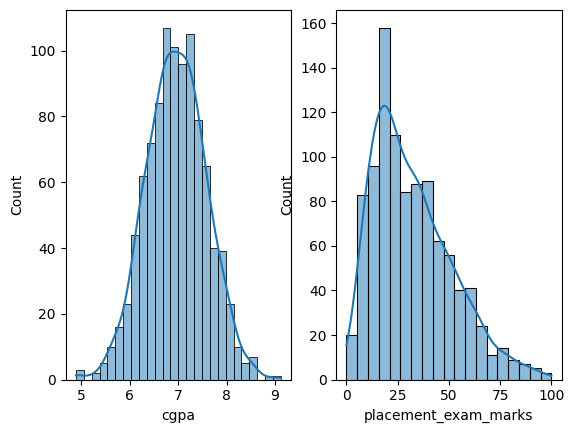

In [14]:
plt.subplot(1,2,1)
sns.histplot(data=df['cgpa'],kde=True)

plt.subplot(1,2,2)
sns.histplot(data=df['placement_exam_marks'],kde=True)

<Axes: xlabel='placement_exam_marks', ylabel='Density'>

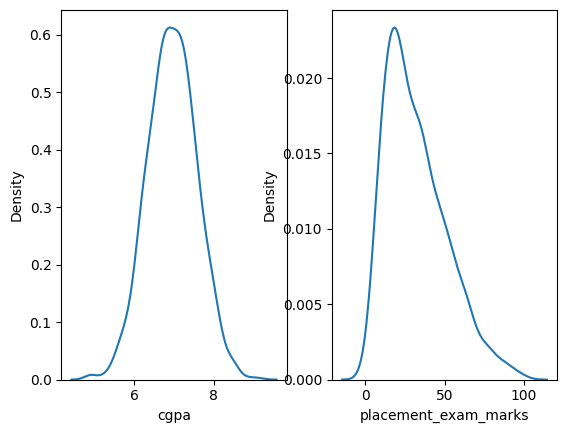

In [17]:
plt.subplot(1,2,1)
sns.kdeplot(data=df['cgpa'])

plt.subplot(1,2,2)
sns.kdeplot(data=df['placement_exam_marks'])

In [18]:
print('Mean of the CGPA:', df['cgpa'].mean())
print('STD of the CGPA:', df['cgpa'].std())
print('Min of the CGPA:', df['cgpa'].min())
print('Max of the CGPA:', df['cgpa'].max())

Mean of the CGPA: 6.96124
STD of the CGPA: 0.6158978751323896
Min of the CGPA: 4.89
Max of the CGPA: 9.12


In [23]:
print('Upper limit of the CGPA:', df['cgpa'].mean() + 3*df['cgpa'].std())
print('Lower limit of the CGPA:', df['cgpa'].mean() - 3*df['cgpa'].std())

Upper limit of the CGPA: 8.808933625397168
Lower limit of the CGPA: 5.113546374602832


In [ ]:
df[(df['cgpa'] > 8.80) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## Trimming (Removal) Technique:

In [26]:
# First Approach:

new_df = df[(df['cgpa'] < 8.80) & (df['cgpa'] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [28]:
# Second Approach:

df['cgpa_zscore'] = ((df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std())

In [29]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [34]:
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [35]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [36]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [ ]:
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


## Capping (Winsorization) Technique:

In [40]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [41]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        df['cgpa'] < lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [42]:
df.shape

(1000, 4)

In [43]:
df.describe()

,cgpa,placement_exam_marks,placed,cgpa_zscore
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.225000,0.489000,-1.465494e-16
std,0.612688,19.130822,0.500129,1.000000e+00
min,5.113546,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,8.808934,100.000000,1.000000,3.505062e+00
